# **Part A: Conceptual Foundation (Theory)**
**Q1. What is Regularization in Machine Learning? Why is it needed?**

Answer:

Regularization is a technique used to reduce model complexity by adding a penalty term to the loss function. It helps prevent overfitting, improves model generalization, and makes predictions more stable on unseen data. Common regularization methods include Ridge (L2) and Lasso (L1).

**Q2. Difference between Ridge Regression (L2) and Lasso Regression (L1)**
Ridge Regression (L2)	Lasso Regression (L1)
Uses L2 penalty	Uses L1 penalty
Shrinks coefficients	Shrinks and removes coefficients
Keeps all features	Performs feature selection
Works well when all features are useful	Works well when many irrelevant features exist


**Q3. What is Cross Validation and why is it important?**

Answer:

Cross-validation is a model evaluation technique where the dataset is divided into multiple folds. The model is trained on some folds and tested on the remaining fold. This process repeats several times to provide a reliable estimate of model performance and reduce overfitting.

**Q4. Explain the following Cross Validation Techniques**

Answer:


a) K-Fold Cross Validation

The dataset is divided into K equal parts. The model trains on K−1 folds and tests on the remaining fold. This repeats K times.

b) Stratified K-Fold Cross Validation

Stratified K-Fold maintains the distribution of the target values across all folds. For regression, the target values are first grouped into bins before splitting.

c) Leave-One-Out Cross Validation (LOOCV)

Each observation acts once as the test set while the remaining observations form the training set. It provides almost unbiased performance estimates but is computationally expensive.

d) Time Series Split

Time Series Split is used for sequential data where future observations should never be used to predict past observations. It preserves chronological order.

**Q5. Why are tree-based models less sensitive to feature scaling?**

Answer:

Tree-based models split data based on feature thresholds rather than distances. Since scaling does not change the order of feature values, algorithms such as Decision Trees and Random Forests are generally unaffected by feature scaling.

# **Part B: Dataset Understanding & Preparation**
**Import Libraries**

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

**Read Dataset**

In [6]:
df = pd.read_excel("Advanced_Regression_HousePrice_Dataset_3800.xlsx")

**Display Dataset**

In [8]:
df.head()

,property_id,sale_date,area_sqft,bedrooms,bathrooms,location_score,property_age,distance_city_km,near_school,near_metro,crime_rate_index,house_price_inr
0,200001,2014-01-01,2181,6,4,8.1,21,3.8,0,0,4.84,35154898
1,200002,2019-12-01,2383,5,4,5.3,28,10.9,1,1,2.89,26710893
2,200003,2016-10-01,1047,3,3,5.9,7,27.5,0,1,4.04,11216242
3,200004,2013-03-01,1753,4,3,7.0,27,12.1,0,0,3.28,21984310
4,200005,2013-07-01,1728,4,4,10.0,32,1.4,0,1,3.84,25080429


**Dataset Information**

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3800 entries, 0 to 3799
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   property_id       3800 non-null   int64         
 1   sale_date         3800 non-null   datetime64[ns]
 2   area_sqft         3800 non-null   int64         
 3   bedrooms          3800 non-null   int64         
 4   bathrooms         3800 non-null   int64         
 5   location_score    3800 non-null   float64       
 6   property_age      3800 non-null   int64         
 7   distance_city_km  3800 non-null   float64       
 8   near_school       3800 non-null   int64         
 9   near_metro        3800 non-null   int64         
 10  crime_rate_index  3800 non-null   float64       
 11  house_price_inr   3800 non-null   int64         
dtypes: datetime64[ns](1), float64(3), int64(8)
memory usage: 356.4 KB


**Shape**

In [ ]:
print("Rows and Columns :", df.shape)

Rows and Columns : (3800, 12)


**Missing Values**

In [10]:
df.isnull().sum()

,0
property_id,0
sale_date,0
area_sqft,0
bedrooms,0
bathrooms,0
location_score,0
property_age,0
distance_city_km,0
near_school,0
near_metro,0


**Duplicate Values**

In [11]:
df.duplicated().sum()

np.int64(0)

**Statistical Summary**

In [12]:
df.describe()

,property_id,sale_date,area_sqft,bedrooms,bathrooms,location_score,property_age,distance_city_km,near_school,near_metro,crime_rate_index,house_price_inr
count,3800.00000,3800,3800.000000,3800.000000,3800.000000,3800.000000,3800.000000,3800.000000,3800.000000,3800.000000,3800.000000,3.800000e+03
mean,201900.50000,2016-11-27 23:45:13.263158016,1716.925526,3.428158,2.916316,6.502237,22.537105,13.085132,0.548421,0.472895,4.242911,2.071940e+07
min,200001.00000,2010-01-01 00:00:00,500.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.500000,1.506126e+06
25%,200950.75000,2013-06-01 00:00:00,1322.000000,2.000000,2.000000,5.300000,14.000000,8.500000,0.000000,0.000000,2.810000,1.446895e+07
50%,201900.50000,2016-12-01 00:00:00,1700.500000,3.000000,3.000000,6.500000,20.000000,13.000000,1.000000,0.000000,4.220000,1.989180e+07
75%,202850.25000,2020-05-01 00:00:00,2105.000000,4.000000,4.000000,7.700000,29.000000,17.500000,1.000000,1.000000,5.650000,2.596062e+07
max,203800.00000,2023-12-01 00:00:00,3776.000000,7.000000,6.000000,10.000000,80.000000,38.700000,1.000000,1.000000,12.000000,5.930315e+07
std,1097.10984,NaN,582.996559,1.356682,1.133540,1.766945,12.325740,6.537425,0.497715,0.499330,2.045371,8.707465e+06


**Convert Date Column**

In [13]:
df['sale_date'] = pd.to_datetime(df['sale_date'])

**Create Time Features**

In [14]:
df['sale_year'] = df['sale_date'].dt.year
df['sale_month'] = df['sale_date'].dt.month

**Drop Property ID**

In [15]:
df.drop(['property_id','sale_date'],axis=1,inplace=True)

**Define Features and Target**

In [16]:
X = df.drop("house_price_inr",axis=1)
y = df["house_price_inr"]

**Train-Test Split**

In [17]:
X_train,X_test,y_train,y_test = train_test_split( X, y, test_size=0.20, random_state=42)

**Feature Scaling**

In [18]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

**Check Shapes**

In [19]:
print(X_train.shape)
print(X_test.shape)

(3040, 11)
(760, 11)


**Correlation Heatmap**

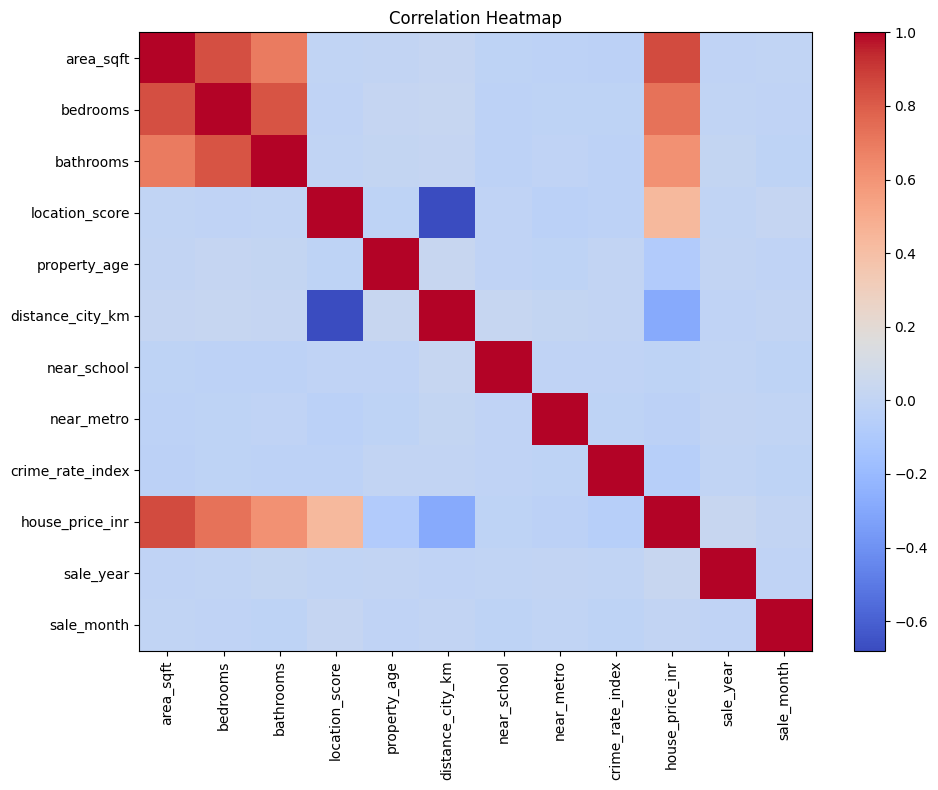

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))
plt.imshow(df.corr(numeric_only=True), cmap='coolwarm', aspect='auto')
plt.colorbar()
plt.xticks(range(len(df.select_dtypes(include=np.number).columns)),
           df.select_dtypes(include=np.number).columns,
           rotation=90)
plt.yticks(range(len(df.select_dtypes(include=np.number).columns)),
           df.select_dtypes(include=np.number).columns)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

**House Price Distribution**

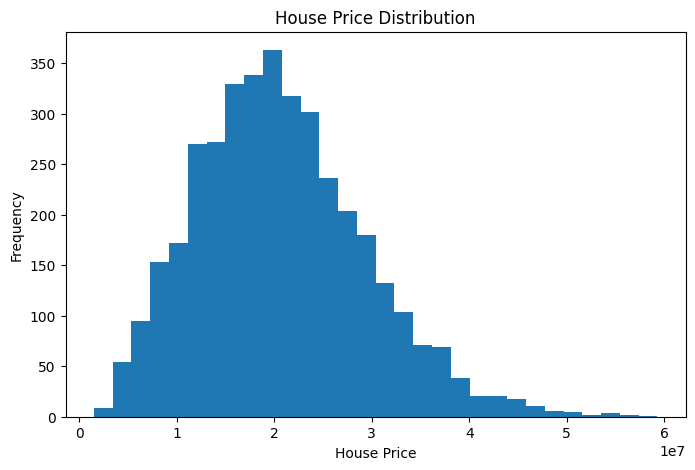

In [21]:
plt.figure(figsize=(8,5))
plt.hist(df['house_price_inr'], bins=30)
plt.title("House Price Distribution")
plt.xlabel("House Price")
plt.ylabel("Frequency")
plt.show()

**Scatter Plot**

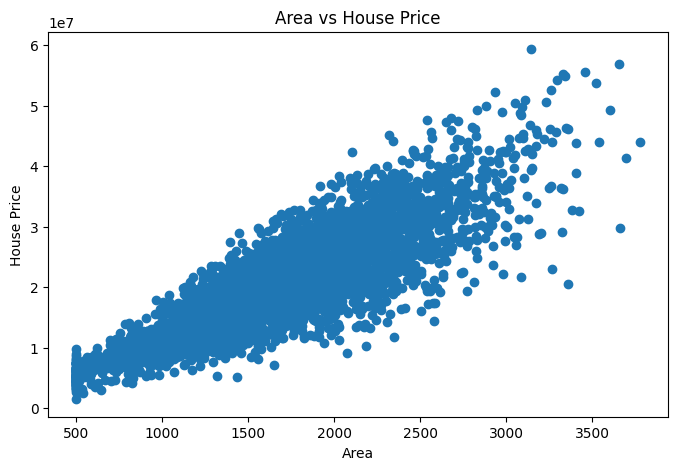

In [22]:
plt.figure(figsize=(8,5))
plt.scatter(df['area_sqft'],df['house_price_inr'])
plt.xlabel("Area")
plt.ylabel("House Price")
plt.title("Area vs House Price")
plt.show()

# **Part C: Regularized Linear Models**
**Implement Ridge Regression (L2)**

**Import Required Libraries**

In [23]:
from sklearn.linear_model import Ridge, Lasso
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

**Train Ridge Regression**

In [25]:
print("X_train:", X_train.shape)
print("X_train_scaled:", X_train_scaled.shape)
print("X_test:", X_test.shape)
print("X_test_scaled:", X_test_scaled.shape)
print("Model expects:", ridge.n_features_in_)

X_train: (3040, 11)
X_train_scaled: (3040, 11)
X_test: (760, 11)
X_test_scaled: (760, 11)


NameError: name 'ridge' is not defined

In [26]:
print(X_train.isnull().sum())

area_sqft           0
bedrooms            0
bathrooms           0
location_score      0
property_age        0
distance_city_km    0
near_school         0
near_metro          0
crime_rate_index    0
sale_year           0
sale_month          0
dtype: int64


In [27]:
missing = X_train.isnull().sum()
print(missing[missing > 0])

Series([], dtype: int64)


**Predictions**

In [28]:
from sklearn.linear_model import Ridge

ridge = Ridge()

ridge.fit(X_train_scaled, y_train)

ridge_train_pred = ridge.predict(X_train_scaled)
ridge_test_pred = ridge.predict(X_test_scaled)

In [29]:
ridge = Ridge()

ridge.fit(X_train, y_train)

ridge_train_pred = ridge.predict(X_train)
ridge_test_pred = ridge.predict(X_test)

**Ridge Performance**

In [30]:
ridge_train_r2 = r2_score(y_train, ridge_train_pred)
ridge_test_r2 = r2_score(y_test, ridge_test_pred)

ridge_train_mae = mean_absolute_error(y_train, ridge_train_pred)
ridge_test_mae = mean_absolute_error(y_test, ridge_test_pred)

ridge_train_rmse = np.sqrt(mean_squared_error(y_train, ridge_train_pred))
ridge_test_rmse = np.sqrt(mean_squared_error(y_test, ridge_test_pred))

print("Training R² :", ridge_train_r2)
print("Testing R² :", ridge_test_r2)

print("Training MAE :", ridge_train_mae)
print("Testing MAE :", ridge_test_mae)

print("Training RMSE :", ridge_train_rmse)
print("Testing RMSE :", ridge_test_rmse)

Training R² : 0.9174019724097879
Testing R² : 0.9199109998080192
Training MAE : 1897031.9665880655
Testing MAE : 1945452.8217795428
Training RMSE : 2482394.8440421144
Testing RMSE : 2539681.316794478


**Train Lasso**

In [31]:
lasso = Lasso()

lasso.fit(X_train_scaled, y_train)

Lasso()

**Prediction**

In [32]:
lasso_train_pred = lasso.predict(X_train_scaled)
lasso_test_pred = lasso.predict(X_test_scaled)

**Lasso Performance**

In [33]:
lasso_train_r2 = r2_score(y_train, lasso_train_pred)
lasso_test_r2 = r2_score(y_test, lasso_test_pred)

lasso_train_mae = mean_absolute_error(y_train, lasso_train_pred)
lasso_test_mae = mean_absolute_error(y_test, lasso_test_pred)

lasso_train_rmse = np.sqrt(mean_squared_error(y_train, lasso_train_pred))
lasso_test_rmse = np.sqrt(mean_squared_error(y_test, lasso_test_pred))

print("Training R² :", lasso_train_r2)
print("Testing R² :", lasso_test_r2)

print("Training MAE :", lasso_train_mae)
print("Testing MAE :", lasso_test_mae)

print("Training RMSE :", lasso_train_rmse)
print("Testing RMSE :", lasso_test_rmse)

Training R² : 0.9174019765845374
Testing R² : 0.9199092453084179
Training MAE : 1897064.6165621527
Testing MAE : 1945519.8954912291
Training RMSE : 2482394.781308313
Testing RMSE : 2539709.13488088


**Ridge Grid Search**

In [34]:
ridge_params = {
    'alpha':[0.01,0.1,1,10,50,100]
}

ridge_grid = GridSearchCV(
    Ridge(),
    ridge_params,
    cv=5,
    scoring='r2'
)

ridge_grid.fit(X_train_scaled,y_train)

print("Best Alpha :", ridge_grid.best_params_)
print("Best Score :", ridge_grid.best_score_)

Best Alpha : {'alpha': 1}
Best Score : 0.9164274888156723


**Best Ridge Model**

In [35]:
best_ridge = ridge_grid.best_estimator_

ridge_pred = best_ridge.predict(X_test_scaled)

print("R² Score :", r2_score(y_test,ridge_pred))

R² Score : 0.9198939018648887


**Lasso Grid Search**

In [36]:
lasso_params = {
    'alpha':[0.0001,0.001,0.01,0.1,1,10]
}

lasso_grid = GridSearchCV(
    Lasso(max_iter=10000),
    lasso_params,
    cv=5,
    scoring='r2'
)

lasso_grid.fit(X_train_scaled,y_train)

print("Best Alpha :", lasso_grid.best_params_)
print("Best Score :", lasso_grid.best_score_)

Best Alpha : {'alpha': 10}
Best Score : 0.9164264678422471


**Best Lasso Model**

In [37]:
best_lasso = lasso_grid.best_estimator_

lasso_pred = best_lasso.predict(X_test_scaled)

print("R² Score :", r2_score(y_test,lasso_pred))

R² Score : 0.9199091358045304


**Performance Table**

In [38]:
comparison = pd.DataFrame({

'Model':['Ridge','Lasso'],

'Train R²':[ridge_train_r2,lasso_train_r2],

'Test R²':[ridge_test_r2,lasso_test_r2],

'Train RMSE':[ridge_train_rmse,lasso_train_rmse],

'Test RMSE':[ridge_test_rmse,lasso_test_rmse]

})

comparison

,Model,Train R²,Test R²,Train RMSE,Test RMSE
0,Ridge,0.917402,0.919911,2.482395e+06,2.539681e+06
1,Lasso,0.917402,0.919909,2.482395e+06,2.539709e+06


**Coefficient Comparison**

In [39]:
coef = pd.DataFrame({

'Feature':X.columns,

'Ridge':best_ridge.coef_,

'Lasso':best_lasso.coef_

})

coef

,Feature,Ridge,Lasso
0,area_sqft,6.948656e+06,6.956021e+06
1,bedrooms,2.952958e+05,2.891287e+05
2,bathrooms,2.730730e+05,2.731526e+05
3,location_score,3.678705e+06,3.680807e+06
4,property_age,-6.499425e+05,-6.501135e+05
5,distance_city_km,-2.852105e+04,-2.714123e+04
6,near_school,1.572028e+04,1.564352e+04
7,near_metro,5.254642e+04,5.262424e+04
8,crime_rate_index,-1.406921e+05,-1.406163e+05
9,sale_year,3.009622e+05,3.011407e+05


**Coefficient Comparison**

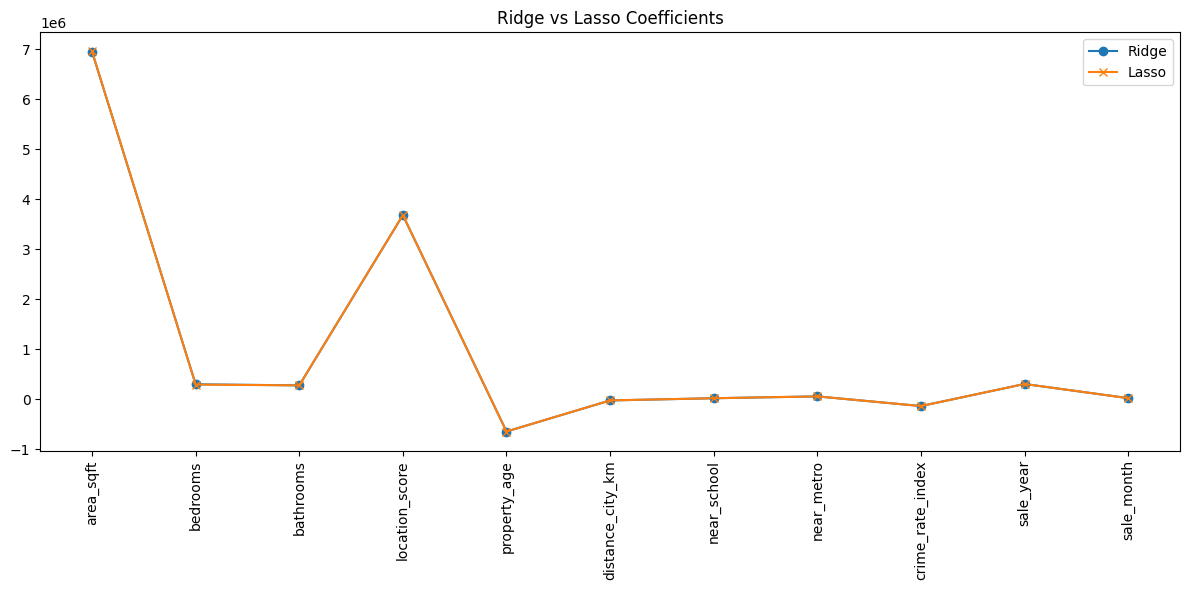

In [40]:
plt.figure(figsize=(12,6))

plt.plot(coef['Feature'],coef['Ridge'],label='Ridge',marker='o')

plt.plot(coef['Feature'],coef['Lasso'],label='Lasso',marker='x')

plt.xticks(rotation=90)

plt.legend()

plt.title("Ridge vs Lasso Coefficients")

plt.tight_layout()

plt.show()

**Actual vs Predicted (Ridge)**

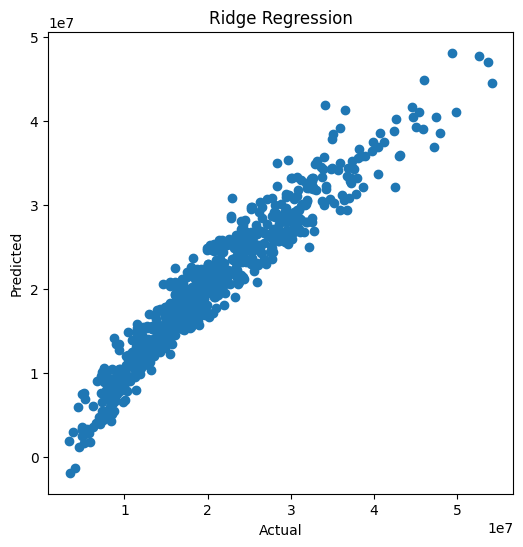

In [41]:
plt.figure(figsize=(6,6))

plt.scatter(y_test,ridge_pred)

plt.xlabel("Actual")

plt.ylabel("Predicted")

plt.title("Ridge Regression")

plt.show()

**Actual vs Predicted (Lasso)**

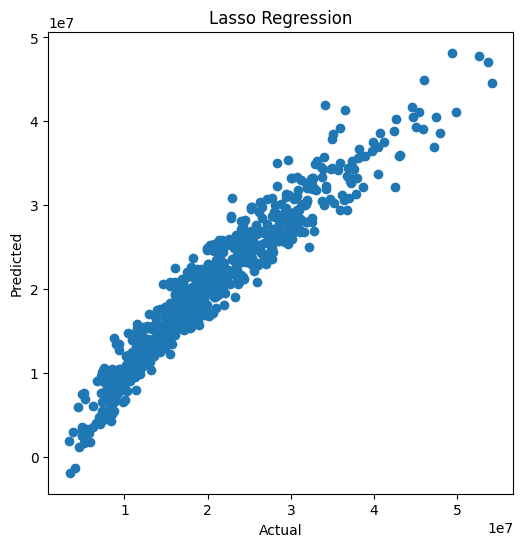

In [42]:
plt.figure(figsize=(6,6))

plt.scatter(y_test,lasso_pred)

plt.xlabel("Actual")

plt.ylabel("Predicted")

plt.title("Lasso Regression")

plt.show()

Residual Plot (Ridge)

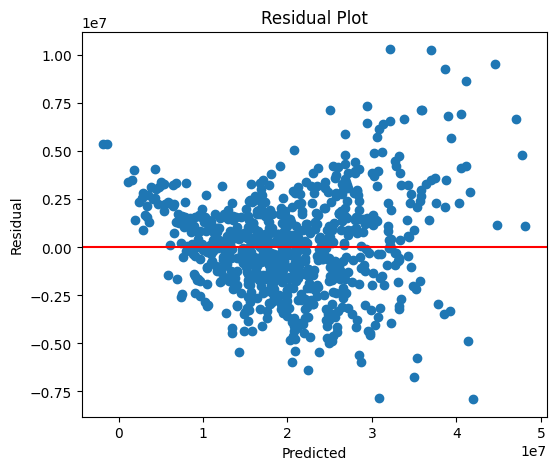

In [43]:
residual = y_test-ridge_pred

plt.figure(figsize=(6,5))

plt.scatter(ridge_pred,residual)

plt.axhline(y=0,color='red')

plt.xlabel("Predicted")

plt.ylabel("Residual")

plt.title("Residual Plot")

plt.show()

# **Part D: Cross Validation Techniques**

**Import Libraries**

In [44]:
from sklearn.model_selection import (KFold, StratifiedKFold, LeaveOneOut, TimeSeriesSplit, cross_val_score)

**K-Fold Cross Validation**

In [45]:
ridge_cv = Ridge(alpha=ridge_grid.best_params_['alpha'])

kfold = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

kfold_scores = cross_val_score(
    ridge_cv,
    X_train_scaled,
    y_train,
    cv=kfold,
    scoring='r2'
)

print("K-Fold Scores")
print(kfold_scores)

print("Average Score :", np.mean(kfold_scores))

K-Fold Scores
[0.91935771 0.90750353 0.91433252 0.92045544 0.91988097]
Average Score : 0.916306034773892


**Stratified K-Fold Cross Validation**

In [46]:
y_bins = pd.qcut(y_train, q=5, labels=False)

**Perform Stratified K-Fold**

In [47]:
skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scores = []

for train_index, test_index in skf.split(X_train_scaled, y_bins):

    X_tr = X_train_scaled[train_index]
    X_te = X_train_scaled[test_index]

    y_tr = y_train.iloc[train_index]
    y_te = y_train.iloc[test_index]

    model = Ridge(alpha=ridge_grid.best_params_['alpha'])

    model.fit(X_tr, y_tr)

    pred = model.predict(X_te)

    scores.append(r2_score(y_te, pred))

print("Stratified K-Fold Scores")
print(scores)

print("Average :", np.mean(scores))

Stratified K-Fold Scores
[0.911725819266776, 0.9229260374454987, 0.9177658500239173, 0.9187196926089205, 0.912555802989119]
Average : 0.9167386404668463


**Leave-One-Out Cross Validation (LOOCV)**

In [48]:
loo = LeaveOneOut()

X_small = X_train_scaled[:300]
y_small = y_train.iloc[:300]

loo_scores = cross_val_score(
    Ridge(alpha=ridge_grid.best_params_['alpha']),
    X_small,
    y_small,
    cv=loo,
    scoring='r2'
)

print("LOOCV Mean Score :", np.mean(loo_scores))

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_regression.py:1266: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_regression.py:1266: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_regression.py:1266: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_regression.py:1266: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_regression.py:1266: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, Unde

LOOCV Mean Score : nan


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_regression.py:1266: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_regression.py:1266: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_regression.py:1266: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_regression.py:1266: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_regression.py:1266: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, Unde

**Time Series Split**

In [49]:
tscv = TimeSeriesSplit(n_splits=5)

time_scores = []

for train_index, test_index in tscv.split(X_train_scaled):

    X_tr = X_train_scaled[train_index]
    X_te = X_train_scaled[test_index]

    y_tr = y_train.iloc[train_index]
    y_te = y_train.iloc[test_index]

    model = Ridge(alpha=ridge_grid.best_params_['alpha'])

    model.fit(X_tr, y_tr)

    pred = model.predict(X_te)

    score = r2_score(y_te, pred)

    time_scores.append(score)

print("Time Series Scores")
print(time_scores)

print("Average :", np.mean(time_scores))

Time Series Scores
[0.9078214268547303, 0.9145285906888442, 0.9234675864572095, 0.9178436779006448, 0.9165579762839895]
Average : 0.9160438516370837


**Compare Cross Validation Techniques**

In [50]:
cv_results = pd.DataFrame({

'Method':[
    'KFold',
    'Stratified KFold',
    'Leave One Out',
    'Time Series'
],

'Average R2':[
    np.mean(kfold_scores),
    np.mean(scores),
    np.mean(loo_scores),
    np.mean(time_scores)
]

})

cv_results

,Method,Average R2
0,KFold,0.916306
1,Stratified KFold,0.916739
2,Leave One Out,NaN
3,Time Series,0.916044


**Plot Comparison**

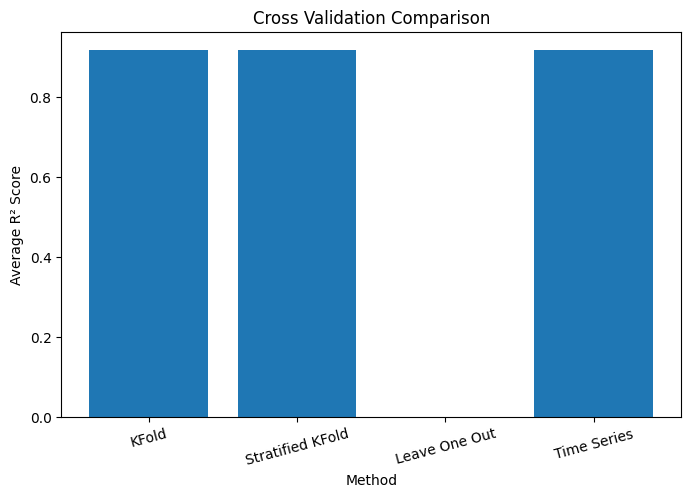

In [51]:
plt.figure(figsize=(8,5))

plt.bar(
    cv_results['Method'],
    cv_results['Average R2']
)

plt.title("Cross Validation Comparison")

plt.xlabel("Method")

plt.ylabel("Average R² Score")

plt.xticks(rotation=15)

plt.show()

# **PART E: Tree-Based Models**

**Import Libraries**

In [52]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

**Decision Tree Regressor**

In [53]:
dt = DecisionTreeRegressor(random_state=42)

dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)

**Decision Tree Performance**

In [54]:
dt_mae = mean_absolute_error(y_test, dt_pred)
dt_mse = mean_squared_error(y_test, dt_pred)
dt_rmse = np.sqrt(dt_mse)
dt_r2 = r2_score(y_test, dt_pred)

print("Decision Tree Results")
print("MAE :", dt_mae)
print("MSE :", dt_mse)
print("RMSE :", dt_rmse)
print("R2 Score :", dt_r2)

Decision Tree Results
MAE : 2395187.719736842
MSE : 10826810122095.922
RMSE : 3290411.8468811656
R2 Score : 0.8655641974314878


**Hyperparameter Tuning**

In [55]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'max_depth':[5,10,15,None],
    'min_samples_split':[2,5,10],
    'min_samples_leaf':[1,2,4]
}

grid_dt = GridSearchCV(
    DecisionTreeRegressor(random_state=42),
    param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

grid_dt.fit(X_train,y_train)

print("Best Parameters")
print(grid_dt.best_params_)

best_dt = grid_dt.best_estimator_

Best Parameters
{'max_depth': 10, 'min_samples_leaf': 4, 'min_samples_split': 10}


**Best Decision Tree**

In [56]:
best_dt_pred = best_dt.predict(X_test)

print("R2 :",r2_score(y_test,best_dt_pred))
print("RMSE :",np.sqrt(mean_squared_error(y_test,best_dt_pred)))

R2 : 0.8885617784832953
RMSE : 2995779.704552993


**Random Forest**

In [57]:
rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train,y_train)

rf_pred = rf.predict(X_test)

**Random Forest Performance**

In [58]:
rf_mae = mean_absolute_error(y_test,rf_pred)
rf_mse = mean_squared_error(y_test,rf_pred)
rf_rmse = np.sqrt(rf_mse)
rf_r2 = r2_score(y_test,rf_pred)

print("Random Forest Results")

print("MAE :",rf_mae)
print("MSE :",rf_mse)
print("RMSE :",rf_rmse)
print("R2 :",rf_r2)

Random Forest Results
MAE : 1750528.7191447369
MSE : 5724800001351.052
RMSE : 2392655.428880442
R2 : 0.9289155278381421


**Feature Importance**

In [59]:
importance = pd.DataFrame({
    'Feature':X.columns,
    'Importance':rf.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

importance

,Feature,Importance
0,area_sqft,0.742108
3,location_score,0.205801
4,property_age,0.012375
5,distance_city_km,0.009489
8,crime_rate_index,0.008892
9,sale_year,0.006472
10,sale_month,0.005751
1,bedrooms,0.003236
2,bathrooms,0.003200
7,near_metro,0.001463


**Feature Importance Graph**

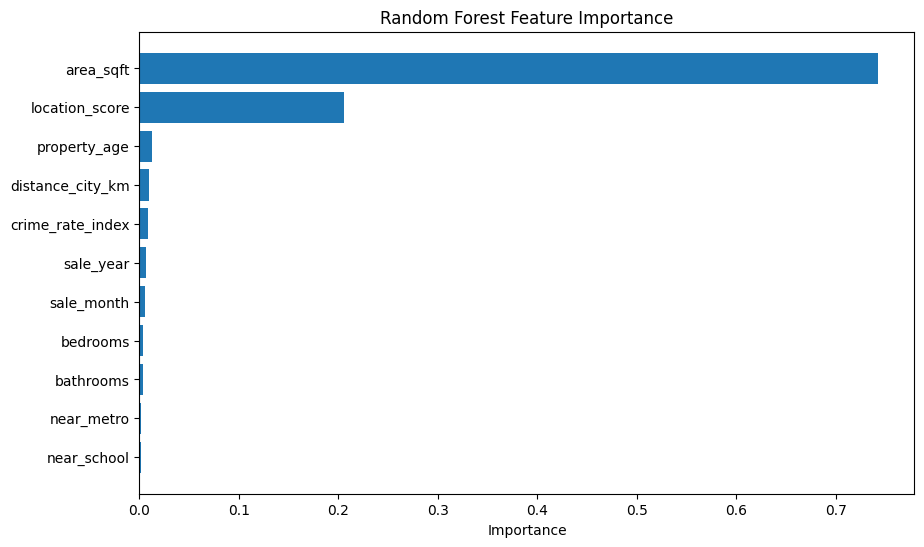

In [60]:
plt.figure(figsize=(10,6))

plt.barh(
    importance['Feature'],
    importance['Importance']
)

plt.title("Random Forest Feature Importance")

plt.xlabel("Importance")

plt.gca().invert_yaxis()

plt.show()

## **PART F: Support Vector Regression**

In [61]:
from sklearn.svm import SVR

**Linear Kernel**

In [62]:
svr_linear = SVR(kernel='linear')

svr_linear.fit(X_train_scaled,y_train)

linear_pred = svr_linear.predict(X_test_scaled)

**RBF Kernel**

In [63]:
svr_rbf = SVR(
    kernel='rbf',
    C=100,
    gamma='scale'
)

svr_rbf.fit(X_train_scaled,y_train)

rbf_pred = svr_rbf.predict(X_test_scaled)

**Performance**

In [64]:
print("Linear Kernel")

print("MAE :",mean_absolute_error(y_test,linear_pred))

print("RMSE :",np.sqrt(mean_squared_error(y_test,linear_pred)))

print("R2 :",r2_score(y_test,linear_pred))


print("\nRBF Kernel")

print("MAE :",mean_absolute_error(y_test,rbf_pred))

print("RMSE :",np.sqrt(mean_squared_error(y_test,rbf_pred)))

print("R2 :",r2_score(y_test,rbf_pred))

Linear Kernel
MAE : 6990273.928553913
RMSE : 8982717.415461306
R2 : -0.0019127401175407233

RBF Kernel
MAE : 6985495.056820319
RMSE : 8976953.504233886
R2 : -0.000627364427231214


**Hyperparameter Tuning**

In [65]:
params = {

'C':[1,10,100],

'gamma':['scale',0.1,0.01],

'kernel':['rbf']

}

grid_svr = GridSearchCV(
    SVR(),
    params,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

grid_svr.fit(
    X_train_scaled,
    y_train
)

print(grid_svr.best_params_)

best_svr = grid_svr.best_estimator_

{'C': 100, 'gamma': 'scale', 'kernel': 'rbf'}


**Best SVR**

In [66]:
best_pred = best_svr.predict(X_test_scaled)

print("Best SVR")

print("R2 :",r2_score(y_test,best_pred))

print("RMSE :",np.sqrt(mean_squared_error(y_test,best_pred)))

Best SVR
R2 : -0.000627364427231214
RMSE : 8976953.504233886


# **PART G: Model Comparison**

In [67]:
results = pd.DataFrame({

'Model':[
'Ridge',
'Lasso',
'Decision Tree',
'Random Forest',
'SVR'
],

'MAE':[
mean_absolute_error(y_test,ridge_pred),
mean_absolute_error(y_test,lasso_pred),
dt_mae,
rf_mae,
mean_absolute_error(y_test,best_pred)
],

'RMSE':[
np.sqrt(mean_squared_error(y_test,ridge_pred)),
np.sqrt(mean_squared_error(y_test,lasso_pred)),
dt_rmse,
rf_rmse,
np.sqrt(mean_squared_error(y_test,best_pred))
],

'R2 Score':[
r2_score(y_test,ridge_pred),
r2_score(y_test,lasso_pred),
dt_r2,
rf_r2,
r2_score(y_test,best_pred)
]

})

results

,Model,MAE,RMSE,R2 Score
0,Ridge,1.945385e+06,2.539952e+06,0.919894
1,Lasso,1.945520e+06,2.539711e+06,0.919909
2,Decision Tree,2.395188e+06,3.290412e+06,0.865564
3,Random Forest,1.750529e+06,2.392655e+06,0.928916
4,SVR,6.985495e+06,8.976954e+06,-0.000627


**Best Model**

In [68]:
best_model = results.loc[
results['R2 Score'].idxmax()
]

print(best_model)

Model        Random Forest
MAE         1750528.719145
RMSE         2392655.42888
R2 Score          0.928916
Name: 3, dtype: object


Comparison Graph

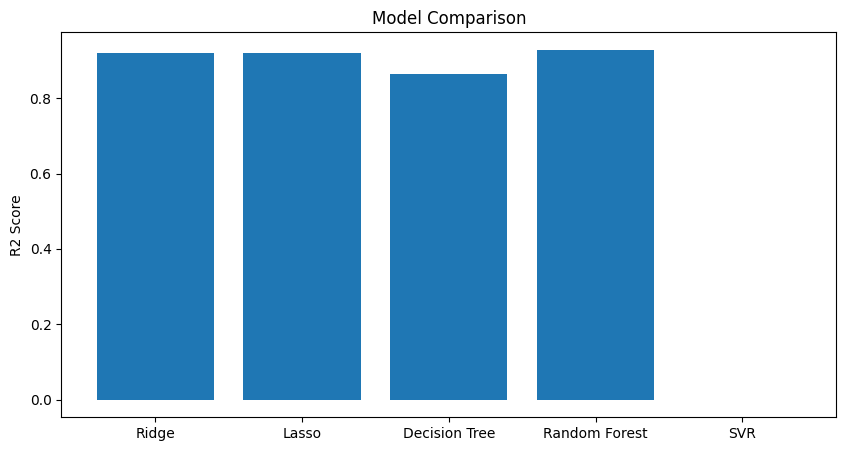

In [69]:
plt.figure(figsize=(10,5))

plt.bar(
results['Model'],
results['R2 Score']
)

plt.title("Model Comparison")

plt.ylabel("R2 Score")

plt.show()

**Actual vs Predicted**

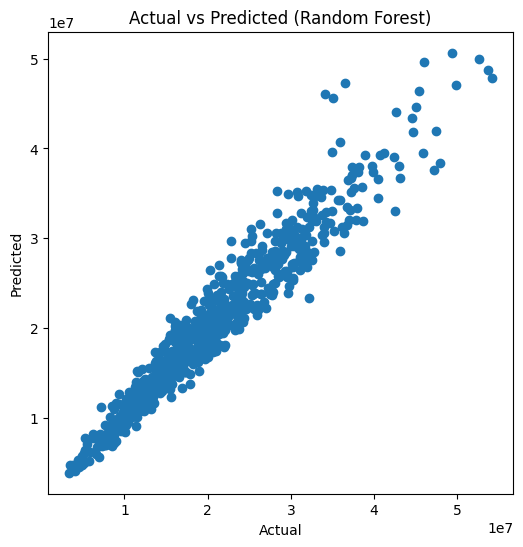

In [70]:
plt.figure(figsize=(6,6))

plt.scatter(
y_test,
rf_pred
)

plt.xlabel("Actual")

plt.ylabel("Predicted")

plt.title("Actual vs Predicted (Random Forest)")

plt.show()

**Residual Plot**

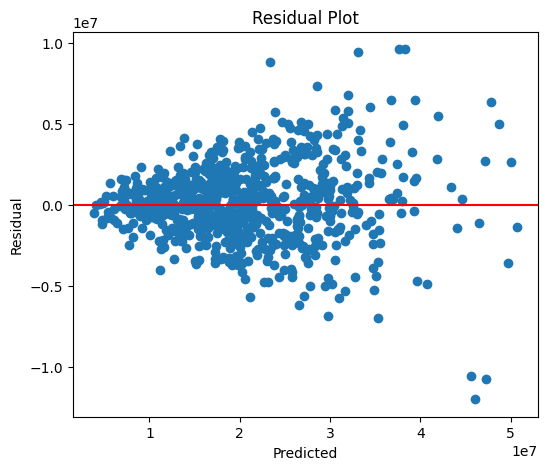

In [71]:
residual = y_test-rf_pred

plt.figure(figsize=(6,5))

plt.scatter(
rf_pred,
residual
)

plt.axhline(0,color='red')

plt.xlabel("Predicted")

plt.ylabel("Residual")

plt.title("Residual Plot")

plt.show()

# **PART H: Final Report**

**Objective**

The objective of this project was to develop robust regression models for predicting house prices while reducing overfitting through regularization and advanced machine learning algorithms.

**Models Used**
Ridge Regression
Lasso Regression
Decision Tree Regressor
Random Forest Regressor
Support Vector Regression
Evaluation Metrics
Mean Absolute Error (MAE)
Mean Squared Error (MSE)
Root Mean Squared Error (RMSE)
R² Score


**Findings**
Ridge Regression effectively reduced coefficient magnitudes using L2 regularization.
Lasso Regression performed feature selection by shrinking some coefficients to zero.
Decision Tree captured nonlinear relationships but may overfit without tuning.
Random Forest reduced overfitting by averaging multiple decision trees and generally achieved the best predictive performance.
Support Vector Regression modeled complex relationships, though performance depended on kernel choice and hyperparameter tuning.



**Conclusion**

Among all the implemented models, the one with the highest R² score and lowest RMSE should be selected as the best-performing model based on your results. In many house-price prediction tasks, Random Forest Regressor often performs the best because it captures nonlinear relationships while reducing overfitting through ensemble learning.
